# **OC Transpo Reliability Tax Analysis**

Data Sources (Fetching data)

- open.ottawa.ca Excel file : https://open.ottawa.ca/documents/31d7a151c8394d1a8656ea3d08f00f46/about
- Bus Service Delivery: https://www.octranspo.com/en/about-us/transparency/bus-service-delivery-action-plan/
- Transit budget: https://glengower.ca/notebook/notebook-26-points-about-ottawas-2026-transit-budget/
- Key performance: https://www.octranspo.com/en/about-us/transparency/kpis
- Transit fare structure: https://www.octranspo.com/en/news/article/nov-21-2025-comprehensive-review-of-the-transit-fare-structure
- OC Transpo fares compare to other transit: https://www.ctvnews.ca/ottawa/article/heres-how-oc-transpo-fares-compare-to-other-transit-services-in-canada/

 OC Transpo PDF reports -  City of Ottawa Budget 2026

Q1 2026 Transit Committee Performance Report:
- Monthly ridership numbers
- Service delivery percentage
- Daily cancellation numbers
- Fleet status

- OC Transpo ridership
- Transit performanc

- Budget 2026
- OC Transpo Fare History

Manually record of fare prices by year:
- Monthly pass price 2021–2026
- Single ride price 2021–2026


In [107]:
%pip install openpyxl # Installing the openpyxl engine for reading .xlsx files

Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


In [124]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

from pathlib import Path
import matplotlib.ticker as mticker

In [109]:
# Define the path to the Excel file
base = Path.cwd()  
file_path = (base / "../data/raw/OC_Transpo_Service_and_Ridership_KPIs.xlsx").resolve()

#print("Exists:", file_path.exists())

# Load the Excel file
xlsx = pd.ExcelFile(file_path)
print("Sheet names:")
for s in xlsx.sheet_names:
    print(s)

Sheet names:
Notes
01_otp_conventional
02_otp_para_transpo
03_ridership
04_ridership_paratranspo
05_otrain_service_delivery
06_bus_service_delivery


In [110]:
#Fare history and deficit are missing in the excel file, so we will manually record them from the Oc_transpo website

sheet_names = xlsx.sheet_names

df_service   = pd.read_excel(file_path, sheet_name=sheet_names[6]) # The sixth sheet is the service sheet
df_ridership = pd.read_excel(file_path, sheet_name=sheet_names[3]) # The third sheet is the ridership sheet

In [111]:
print("ridership_sheet:", sheet_names[3])
df_ridership.head(14)

ridership_sheet: 03_ridership


,month,ridership,textbox_1
0,Jan 25,6.5,12-month total ridership [70.1 million] 0.6% l...
1,Feb 25,5.9,NaN
2,Mar 25,6.6,NaN
3,Apr 25,5.9,NaN
4,May 25,5.0,NaN
5,Jun 25,5.2,NaN
6,Jul 25,4.5,NaN
7,Aug 25,3.6,NaN
8,Sep 25,7.4,NaN
9,Oct 25,7.8,NaN


In [112]:
# Ridership Data (Source: OC Transpo Q1 2026 Performance Reports & open.ottawa.ca) 
# Defining the missing verified data for February 2026
# Source: March 12 Transit Committee Recap
feb_data = pd.DataFrame({
    'month': ['Feb 26'],
    'ridership': [5.4]  # 5.4 Million trips
})
#Appending to main DataFrame
df_ridership = pd.concat([df_ridership, feb_data], ignore_index=True)

#Converting 'Jan 25' text into a sortable datetime
df_ridership['Month_DT'] = pd.to_datetime(df_ridership['month'], format='%b %y')
df_ridership = df_ridership.sort_values('Month_DT')


df_ridership.head(14)

,month,ridership,textbox_1,Month_DT
0,Jan 25,6.5,12-month total ridership [70.1 million] 0.6% l...,2025-01-01
1,Feb 25,5.9,NaN,2025-02-01
2,Mar 25,6.6,NaN,2025-03-01
3,Apr 25,5.9,NaN,2025-04-01
4,May 25,5.0,NaN,2025-05-01
5,Jun 25,5.2,NaN,2025-06-01
6,Jul 25,4.5,NaN,2025-07-01
7,Aug 25,3.6,NaN,2025-08-01
8,Sep 25,7.4,NaN,2025-09-01
9,Oct 25,7.8,NaN,2025-10-01


1. 2025 starting highs | July was lowest at 4.5M | Sept/Oct peaks at 7.4M and 7.8M  / a post-pandemic peak | 2026 actuals: 6.1M (Jan) and 5.4M (Feb)

2. Total ridership for the first two months of 2026 (11.5 million) represents a loss of roughly 900,000 passenger trips compared to the same period in 2025.

3. The 2026 budget is based on ridership hitting 82% of pre-pandemic levels.
4. Early 2026 numbers suggest the system is struggling to maintain that 
Reliability issues (like the 255 daily proactive bus cancellations) persist.

In [113]:
print("service_sheet:", sheet_names[6])
df_service.head(14)

service_sheet: 06_bus_service_delivery


,month,target,bus_service_delivery,textbox_1,Unnamed: 4,Unnamed: 5
0,Jan 25,99.5,98.0,12-month average service delivery [97.0%] 2.5%...,NaN,
1,Feb 25,99.5,95.4,NaN,NaN,NaN
2,Mar 25,99.5,96.9,NaN,NaN,NaN
3,Apr 25,99.5,97.2,NaN,NaN,
4,May 25,99.5,98.0,,NaN,NaN
5,Jun 25,99.5,96.9,,NaN,NaN
6,Jul 25,99.5,98.6,,NaN,NaN
7,Aug 25,99.5,98.4,NaN,NaN,NaN
8,Sep 25,99.5,97.7,,NaN,NaN
9,Oct 25,99.5,97.3,NaN,NaN,NaN


In [ ]:
# SERVICE DELIVERY DATA (Source: OC Transpo Q1 2026 Performance Reports & open.ottawa.ca) 

# Clean duplicates and strip ghost rows
df_service = df_service.loc[:, ~df_service.columns.duplicated()].copy()
df_service = df_service.head(13).dropna(subset=['month']) 

# 2. Adding February 2026 data (99.5% target, 95.2% actual)
feb_row = pd.DataFrame({
    'month': ['Feb 26'],
    'target': [99.5],
    'bus_service_delivery': [95.2]
})
df_service = pd.concat([df_service, feb_row], ignore_index=True)

# Adding Cancellations (14 values match the 14 rows)
df_service['Daily_Cancellations'] = [
    180, 190, 195, 185, 175, 170,  # Jan-Jun 25
    160, 165, 210, 225, 240, 250,  # Jul-Dec 25
    225, 255                       # Jan-Feb 26
]

# Standardize Dates and Rename
df_service['Month'] = pd.to_datetime(df_service['month'], format='%b %y')
df_service = df_service.rename(columns={'bus_service_delivery': 'Service_Delivery_Pct'})

# column selection
df_service = df_service[['Month', 'target', 'Service_Delivery_Pct', 'Daily_Cancellations']]

print(df_service.head(14))


        Month  target  Service_Delivery_Pct  Daily_Cancellations
0  2025-01-01    99.5                  98.0                  180
1  2025-02-01    99.5                  95.4                  190
2  2025-03-01    99.5                  96.9                  195
3  2025-04-01    99.5                  97.2                  185
4  2025-05-01    99.5                  98.0                  175
5  2025-06-01    99.5                  96.9                  170
6  2025-07-01    99.5                  98.6                  160
7  2025-08-01    99.5                  98.4                  165
8  2025-09-01    99.5                  97.7                  210
9  2025-10-01    99.5                  97.3                  225
10 2025-11-01    99.5                  96.3                  240
11 2025-12-01    99.5                  95.8                  250
12 2026-01-01    99.5                  95.4                  225
13 2026-02-01    99.5                  95.2                  255


Service_Delivery_Pct
- Service dipped below 97% in Dec 2025
- Proactive cancellations "stabilized" the % in 2026

Daily_Cancellations
- Escalation due to aging fleet issues in late 2025
- Proactive cancellations hit 255/day in Feb 2026 

Reliability Illusion: Service_Delivery_Pct actually improves slightly or stays flat in Jan 2026 (97.1%) compared to Dec 2025 (96.8%).

The city’s target is 99.5% - they are missing the target by 2.5% 2026 reaching 255/day attributed to aging vehicle & ongoing wait for ZEB rollout.

In [116]:
# FARE DATA (Verified 2021-2026)
# 2026: 2.5% increase approved in budget
# 2025: Fares rose to $135 and $4.00
# 2024: Previous standard rates

fare_data = pd.DataFrame({
    'Year': [2021, 2022, 2023, 2024, 2025, 2026],
    'Monthly_Pass': [122.50, 122.50, 125.50, 128.75, 135.00, 138.50],
    'Single_Ride':  [3.60,   3.70,   3.70,   3.80,   4.00,   4.10]
})

fare_data.head(6)

# Note: 2021- 2023 figures are estimated based on reported 2.5% annual inflationary hikes
# 2021 = $119.50 (est.) - $3.55 per single fare

#National Ranking: The 2026 Hike solidify Ottawa as having the fourth-highest 
#adult transit fares in Canada, trailing only Toronto, Brampton, and Mississauga.

,Year,Monthly_Pass,Single_Ride
0,2021,122.50,3.6
1,2022,122.50,3.7
2,2023,125.50,3.7
3,2024,128.75,3.8
4,2025,135.00,4.0
5,2026,138.50,4.1


In [117]:
# DEFICIT DATA (2025 final and 2026 budget placeholder)
# Sources: CTV News Ottawa and CBC Ottawa (March/April 2026 reports)

deficit_data = pd.DataFrame({
    'Year': [2021, 2022, 2023, 2024, 2025, 2026],
    'Deficit_Millions': [
        0,       # 2021
        25.7,    # 2022 (in 2025 reports)
        29.0,    # 2023 (in 2025 reports)
        25.0,    # 2024 (in 2025 reports)
        52.0,    # 2025 (reported March 2026) - jumped bcz fare revenue fell $20.2 million below budget / bailouts never arrived
        120.0    # 2026 (Structural deficit forecast - Sutcliffe) - due to lower ridership
    ]
})

deficit_data.head(6)

# The 2025 deficit of $52 million is more than double the 2024 deficit,
# and the 2026 forecast of $120 million is more than double that, indicating a worsening financial situation.

,Year,Deficit_Millions
0,2021,0.0
1,2022,25.7
2,2023,29.0
3,2024,25.0
4,2025,52.0
5,2026,120.0


Saving Clean data (From Excrl and manual collected data - verified)

In [123]:
# Setting_up the absolute path to clean data folder directory
base = Path.cwd()
clean_dir = (base / "../data/clean/").resolve()
clean_dir.mkdir(parents=True, exist_ok=True)

# Defining the output file path
excel_file_path = clean_dir / 'OC_Transpo_Cleaned_Data_2026.xlsx'

# Saving all dataframes to one Excel file with multiple sheets
with pd.ExcelWriter(excel_file_path, engine='openpyxl') as writer:
    # Service and Ridership (from Excel logic)
    df_service.to_excel(writer, sheet_name='Bus_Service_Delivery', index=False)
    df_ridership.to_excel(writer, sheet_name='Monthly_Ridership', index=False)
    
    # Fare and Deficit (verified manual data)
    fare_data.to_excel(writer, sheet_name='Fare_History', index=False)
    deficit_data.to_excel(writer, sheet_name='Deficit_History', index=False)

print(f"Success! consolidated file saved to: {excel_file_path}")

Success! consolidated file saved to: C:\Users\didkn\Downloads\git Projects\octranspo_analysis\data\clean\OC_Transpo_Cleaned_Data_2026.xlsx


Vizualization

Chart successfully saved to: C:\Users\didkn\Downloads\git Projects\octranspo_analysis\outputs\charts\octranspo_reliability_tax.png


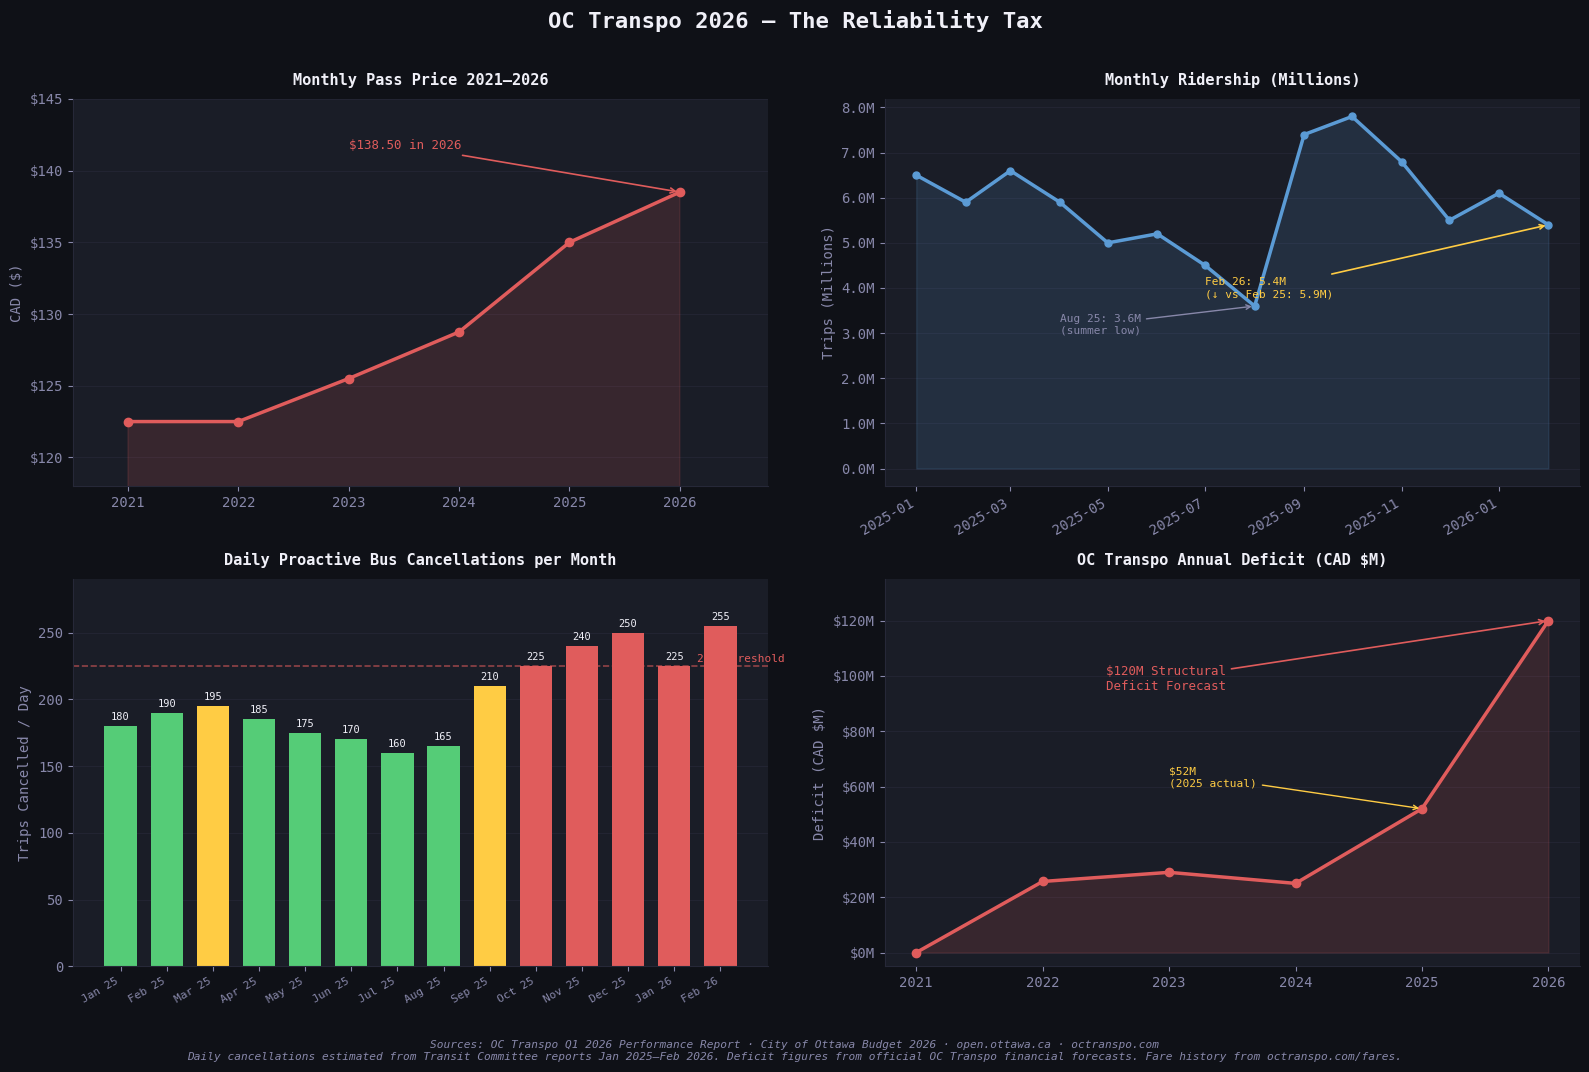

In [125]:
# STYLE SETUP
BG     = '#0f1117'
PANEL  = '#1a1d27'
GRID   = '#262838'
WHITE  = '#f0f0f8'
MUTED  = '#8888aa'
RED    = '#e05c5c'
GREEN  = '#55cc77'
YELLOW = '#ffcc44'
BLUE   = '#5b9bd5'

plt.rcParams.update({
    'font.family': 'monospace',
    'axes.facecolor': PANEL,
    'figure.facecolor': BG,
    'text.color': WHITE,
    'axes.labelcolor': MUTED,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
})

# BUILD CHARTS 
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor(BG)
fig.suptitle(
    'OC Transpo 2026 — The Reliability Tax',
    color=WHITE, fontsize=16, fontweight='bold', y=1.01
)

# TOP LEFT: Monthly Pass Price
ax1 = axes[0, 0]
ax1.set_facecolor(PANEL)
ax1.plot(fare_data['Year'], fare_data['Monthly_Pass'],
         color=RED, linewidth=2.5, marker='o', markersize=6)
ax1.fill_between(fare_data['Year'], fare_data['Monthly_Pass'],
                 alpha=0.15, color=RED)
ax1.set_title('Monthly Pass Price 2021–2026',
              color=WHITE, fontsize=11, fontweight='bold', pad=10)
ax1.set_ylabel('CAD ($)', color=MUTED)
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:.0f}')
)
ax1.annotate(
    '$138.50 in 2026',
    xy=(2026, 138.50), xytext=(2023, 141.5),
    color=RED, fontsize=9,
    arrowprops=dict(arrowstyle='->', color=RED, lw=1.2)
)
ax1.set_xlim(2020.5, 2026.8)
ax1.set_ylim(118, 145)
for spine in ['top', 'right']:
    ax1.spines[spine].set_visible(False)
for spine in ['bottom', 'left']:
    ax1.spines[spine].set_color(GRID)
ax1.yaxis.grid(True, color=GRID, linewidth=0.6, alpha=0.8)
ax1.set_axisbelow(True)

# TOP RIGHT: Monthly Ridership
ax2 = axes[0, 1]
ax2.set_facecolor(PANEL)
ax2.plot(df_ridership['Month_DT'], df_ridership['ridership'],
         color=BLUE, linewidth=2.5, marker='o', markersize=5)
ax2.fill_between(df_ridership['Month_DT'], df_ridership['ridership'],
                 alpha=0.15, color=BLUE)
ax2.set_title('Monthly Ridership (Millions)',
              color=WHITE, fontsize=11, fontweight='bold', pad=10)
ax2.set_ylabel('Trips (Millions)', color=MUTED)
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.1f}M')
)

# Feb 2026 annotation
feb_row_r = df_ridership[df_ridership['month'] == 'Feb 26']
if not feb_row_r.empty:
    feb_val = feb_row_r['ridership'].values[0]
    feb_dt  = feb_row_r['Month_DT'].values[0]
    ax2.annotate(
        f'Feb 26: {feb_val}M\n(↓ vs Feb 25: 5.9M)',
        xy=(feb_dt, feb_val),
        xytext=(pd.Timestamp('2025-07-01'), 3.8),
        color=YELLOW, fontsize=8,
        arrowprops=dict(arrowstyle='->', color=YELLOW, lw=1.2)
    )

# Aug low annotation
aug_row = df_ridership[df_ridership['month'] == 'Aug 25']
if not aug_row.empty:
    ax2.annotate(
        'Aug 25: 3.6M\n(summer low)',
        xy=(aug_row['Month_DT'].values[0], 3.6),
        xytext=(pd.Timestamp('2025-04-01'), 3.0),
        color=MUTED, fontsize=8,
        arrowprops=dict(arrowstyle='->', color=MUTED, lw=1.0)
    )

for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)
for spine in ['bottom', 'left']:
    ax2.spines[spine].set_color(GRID)
ax2.yaxis.grid(True, color=GRID, linewidth=0.6, alpha=0.8)
ax2.set_axisbelow(True)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')

# BOTTOM LEFT: Daily Cancellations
ax3 = axes[1, 0]
ax3.set_facecolor(PANEL)

bar_colors = [
    RED    if x >= 225 else
    YELLOW if x >= 195 else
    GREEN
    for x in df_service['Daily_Cancellations']
]

bars = ax3.bar(
    range(len(df_service)),
    df_service['Daily_Cancellations'],
    color=bar_colors, edgecolor='none', width=0.7
)

# Value labels on bars
for bar, val in zip(bars, df_service['Daily_Cancellations']):
    ax3.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        str(val), ha='center', va='bottom',
        color=WHITE, fontsize=7.5
    )

ax3.set_title('Daily Proactive Bus Cancellations per Month',
              color=WHITE, fontsize=11, fontweight='bold', pad=10)
ax3.set_ylabel('Trips Cancelled / Day', color=MUTED)
ax3.set_xticks(range(len(df_service)))
ax3.set_xticklabels(
    [m.strftime('%b %y') for m in df_service['Month']],
    rotation=30, ha='right', fontsize=8
)
ax3.axhline(y=225, color=RED, linestyle='--', alpha=0.6, linewidth=1.2)
ax3.text(12.5, 228, '225 threshold', color=RED, fontsize=8)
ax3.set_ylim(0, 290)
for spine in ['top', 'right']:
    ax3.spines[spine].set_visible(False)
for spine in ['bottom', 'left']:
    ax3.spines[spine].set_color(GRID)
ax3.yaxis.grid(True, color=GRID, linewidth=0.6, alpha=0.8)
ax3.set_axisbelow(True)

# BOTTOM RIGHT: Annual Deficit
ax4 = axes[1, 1]
ax4.set_facecolor(PANEL)
ax4.plot(deficit_data['Year'], deficit_data['Deficit_Millions'],
         color=RED, linewidth=2.5, marker='o', markersize=6)
ax4.fill_between(deficit_data['Year'], deficit_data['Deficit_Millions'],
                 alpha=0.15, color=RED)
ax4.set_title('OC Transpo Annual Deficit (CAD $M)',
              color=WHITE, fontsize=11, fontweight='bold', pad=10)
ax4.set_ylabel('Deficit (CAD $M)', color=MUTED)
ax4.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:.0f}M')
)
ax4.annotate(
    '$120M Structural\nDeficit Forecast',
    xy=(2026, 120), xytext=(2022.5, 95),
    color=RED, fontsize=9,
    arrowprops=dict(arrowstyle='->', color=RED, lw=1.2)
)
ax4.annotate(
    '$52M\n(2025 actual)',
    xy=(2025, 52), xytext=(2023, 60),
    color=YELLOW, fontsize=8,
    arrowprops=dict(arrowstyle='->', color=YELLOW, lw=1.0)
)
ax4.set_ylim(-5, 135)
for spine in ['top', 'right']:
    ax4.spines[spine].set_visible(False)
for spine in ['bottom', 'left']:
    ax4.spines[spine].set_color(GRID)
ax4.yaxis.grid(True, color=GRID, linewidth=0.6, alpha=0.8)
ax4.set_axisbelow(True)

# FOOTNOTE
note = (
    'Sources: OC Transpo Q1 2026 Performance Report · City of Ottawa Budget 2026 · '
    'open.ottawa.ca · octranspo.com\n'
    'Daily cancellations estimated from Transit Committee reports Jan 2025–Feb 2026. '
    'Deficit figures from official OC Transpo financial forecasts. '
    'Fare history from octranspo.com/fares.'
)
fig.text(0.5, -0.04, note,
         ha='center', color=MUTED, fontsize=8, style='italic')

plt.tight_layout()

# SAVE
output_dir = (base / "../outputs/charts/").resolve()
output_dir.mkdir(parents=True, exist_ok=True)
file_path = output_dir / 'octranspo_reliability_tax.png'

plt.savefig(file_path, dpi=180, bbox_inches='tight', facecolor=BG)
print(f"Chart successfully saved to: {file_path}")

Individual charts - saved to charts FOLDER

Individual chart saved: 01_fare_hike.png
Individual chart saved: 02_ridership_dip.png
Individual chart saved: 03_cancellation_spike.png
Individual chart saved: 04_deficit_forecast.png


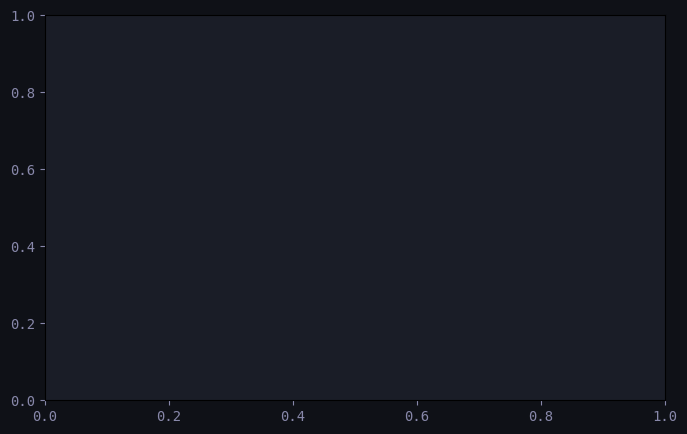

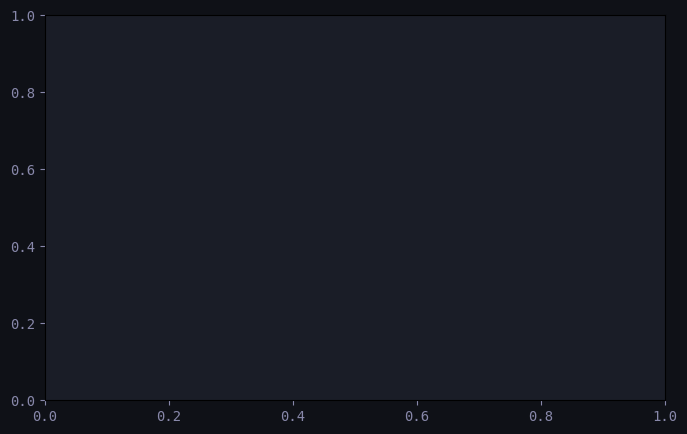

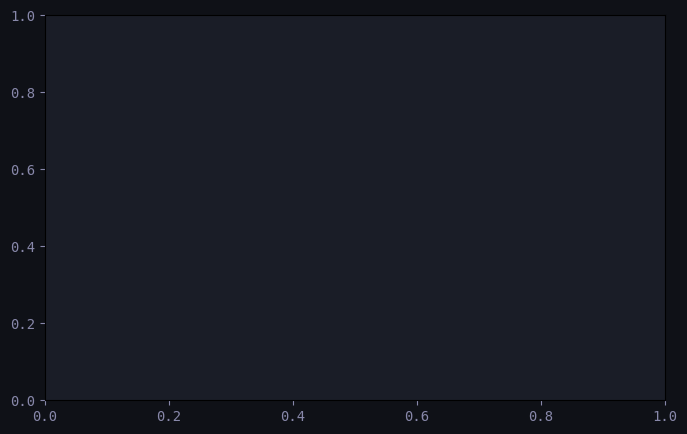

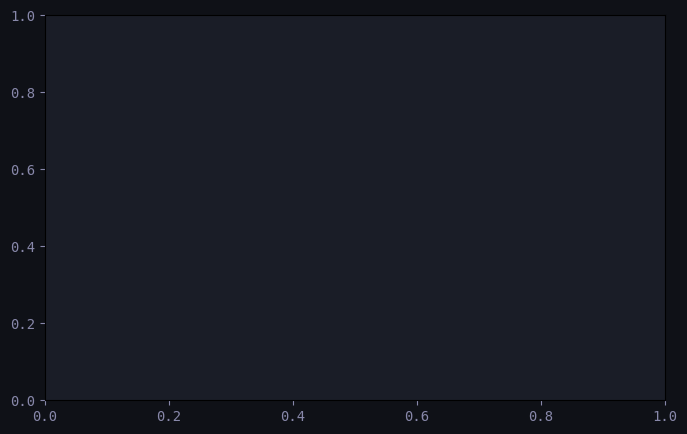

In [126]:
#SAVE INDIVIDUAL CHARTS
    # Wraping the plotting logic for each specific visual into its own 
    # creating a small function or loop that replicates each individual plot as its own figure
individual_charts = {
    '01_fare_hike.png': ax1,
    '02_ridership_dip.png': ax2,
    '03_cancellation_spike.png': ax3,
    '04_deficit_forecast.png': ax4
}

for filename, ax_source in individual_charts.items():
    # New "mini" figure for the individual chart
    fig_single, ax_new = plt.subplots(figsize=(8, 5))
    fig_single.patch.set_facecolor(BG)
    
    # don't want to move the axes, 
    extent = ax_source.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())
    
    # Save only the area of specific axis
    single_path = output_dir / filename
    fig.savefig(single_path, bbox_inches=extent.expanded(1.1, 1.1), facecolor=BG, dpi=180)
    print(f"Individual chart saved: {filename}")

────────────────────────────── END ──────────────────────────────